# GODMAX multi-probe theory comparison

This notebook compares analytic GODMAX two-point theory to the `fast1024` xDESI multi-probe NaMaster measurement.  The numerical comparison is done in saved decoupled `C_ell` bandpower space after `theory_to_data_vector` applies the exact NaMaster windows, HEALPix pixel windows, ACT beams/filters, DES shear sign convention, and kSZ velocity normalization.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np

REPO = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX')
SURVEY_DIR = REPO / 'notebooks' / 'xDESI' / 'survey_measure'
for path in (SURVEY_DIR, REPO / 'src'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import godmax_multiprobe_theory_utils as gmt

CONFIG_PATH = REPO / 'param_files' / 'xDESI' / 'params_multiprobe_fast1024_true_nz_theory.yaml'
CONFIG_PATH

PosixPath('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/param_files/xDESI/params_multiprobe_fast1024_true_nz_theory.yaml')

## Load path-backed inputs

The YAML intentionally stores HDF5 paths rather than long n(z) arrays. This cell reads the measurement/map products, validates that the DESI lens kernels are calibrated true-redshift n(z) curves, injects GODMAX-ready n(z) dictionaries, and computes per-photo-z-bin HOD comoving number-density targets from the measured DESI angular density.

In [2]:
cfg = gmt.load_comparison_config(CONFIG_PATH)
cfg = gmt.materialize_nz_inputs(cfg)
cfg = gmt.compute_desi_nbar_comoving(cfg)
summary = gmt.validation_summary(cfg)
print(json.dumps(gmt.to_jsonable(summary), indent=2))

measurement = gmt.load_measurement_data(cfg['paths']['measurement_h5'])
print(f"n_spectra={len(measurement.names)}, vector_length={measurement.data_vector.size}")
assert len(measurement.names) == 46
assert measurement.data_vector.size == 460

{
  "measurement_h5": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster_true_nz/fast1024/xdesi_multiprobe_cls_cov_nside1024_lmax1024_nbin10_linear.h5",
  "map_h5": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/xDESI/processed/multiprobe_namaster_true_nz/fast1024/xdesi_multiprobe_maps_nside1024_lmax1024_nbin10_linear.h5",
  "lmax": 1024,
  "des_source_nz_shape": [
    4,
    300
  ],
  "desi_lens_nz_shape": [
    4,
    74
  ],
  "desi_lens_redshift_kind": "spectroscopic_calibrated_true_redshift",
  "desi_lens_nz_provenance": {
    "ksz_sigma_true_gas_calibration_json": "{\n  \"bin_assignment\": \"by_z_photo\",\n  \"c_km_s_convention\": 300000.0,\n  \"corrcoef_v_rec_v_true\": {\n    \"1\": 0.6871109287591863,\n    \"2\": 0.6683324285379622,\n    \"3\": 0.6210174474653414,\n    \"4\": 0.4660139572002138\n  },\n  \"description\": \"sigma_true_gas calibration for the DESI DR10 extended photometric tomographic bins in the ACTxDESI transfer package.\",\n  

## DESI true n(z) diagnostic

This diagnostic contrasts the calibrated true-redshift kernels used for theory with the catalog `Z_PHOT_MEDIAN` histograms saved for inspection only.


[
  {
    "pz": 1,
    "true_norm": 1.0,
    "true_mean_z": 0.4680440395710297,
    "photoz_mean_z": 0.47130571815635464
  },
  {
    "pz": 2,
    "true_norm": 1.0,
    "true_mean_z": 0.6327928298079234,
    "photoz_mean_z": 0.6349917312701208
  },
  {
    "pz": 3,
    "true_norm": 1.0,
    "true_mean_z": 0.7912852093519888,
    "photoz_mean_z": 0.7964536682401577
  },
  {
    "pz": 4,
    "true_norm": 0.9999999999999999,
    "true_mean_z": 0.9259410159482504,
    "photoz_mean_z": 0.9181863774297646
  }
]


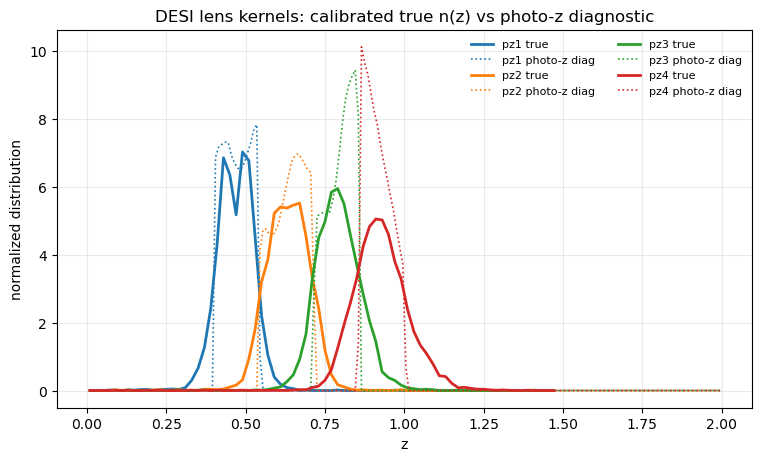

In [5]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline
md = cfg['metadata']
z_true = np.asarray(md['lens_z_mid'])
dndz_true = np.asarray(md['lens_dndz'])
photoz = md.get('lens_photoz_diagnostic') or {}
z_photo = None if photoz.get('z_mid') is None else np.asarray(photoz['z_mid'])
dndz_photo = None if photoz.get('dndz_by_pz') is None else np.asarray(photoz['dndz_by_pz'])

rows = []
for i in range(4):
    rows.append({
        'pz': i + 1,
        'true_norm': float(np.trapz(dndz_true[i], z_true)),
        'true_mean_z': float(np.trapz(z_true * dndz_true[i], z_true)),
        'photoz_mean_z': float(np.trapz(z_photo * dndz_photo[i], z_photo)) if z_photo is not None else np.nan,
    })
print(json.dumps(rows, indent=2))

fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in range(4):
    color = colors[i % len(colors)]
    ax.plot(z_true, dndz_true[i], color=color, lw=2.0, label=f'pz{i + 1} true')
    if z_photo is not None:
        ax.plot(z_photo, dndz_photo[i], color=color, lw=1.2, ls=':', label=f'pz{i + 1} photo-z diag')
ax.set_xlabel('z')
ax.set_ylabel('normalized distribution')
ax.set_title('DESI lens kernels: calibrated true n(z) vs photo-z diagnostic')
ax.grid(True, alpha=0.25)
ax.legend(ncol=2, fontsize=8, frameon=False)
plt.show()


In [6]:
# save the four true n(z) distributions to a file for later use:
saved = {}
for i in range(4):
    saved[f'pz{i + 1}'] = {
        'z': z_true.tolist(),
        'dndz': dndz_true[i].tolist()
    }

import pickle as pkl
pkl.dump(saved, open(REPO / 'notebooks' / 'xDESI' / 'survey_measure' / 'saved_true_nz.pkl', 'wb'))




## Build GODMAX theory

Two GODMAX objects are built: one with DES source weak-lensing kernels and one with CMB lensing for ACT kappa.  The helper sets `ell_array = arange(2, lmax+1)` so the smooth theory is evaluated at integer multipoles before measurement windows are applied.

In [ ]:
models = gmt.build_godmax_models(cfg)
ell_theory = gmt.model_ell_array(models)
print(f"theory ell: {ell_theory[0]}..{ell_theory[-1]} n={ell_theory.size}")
print('modeling:', models.get('modeling'))
print(f"shared WL source bins={models['wl'].nbins}, lens bins={models['wl'].nbins_lens}, model_galaxies={models['wl'].model_galaxies}")
for pz_bin, obj in models['gal_wl_by_pz'].items():
    print(f"pz{pz_bin} WL lens bins={obj.nbins_lens}; CMB lens bins={models['gal_cmb_by_pz'][pz_bin].nbins_lens}")

The kSZ measurement is special: the theory dictionary provides `desi_g_tau_pz{i}`, and `theory_to_data_vector` converts that to the saved raw `C_ell^{pi,T_uK}` using the photometric velocity calibration.  For plots and printed kSZ diagnostics below, we immediately transform both data and theory to the positive convention `-D_ell^{pi,T}`.

In [ ]:
theory_cls, tau_diag = gmt.extract_theory_cls_from_models(models, cfg['metadata'], return_diagnostics=True)
missing = gmt.validate_theory_keys(cfg['paths']['measurement_h5'], theory_cls)
if missing:
    raise KeyError('Missing theory spectra: ' + ', '.join(missing))

bad = {key: value for key, value in theory_cls.items() if not np.all(np.isfinite(value))}
if bad:
    raise ValueError(f'Non-finite smooth theory spectra: {list(bad)[:8]}')
print(f"smooth theory keys={len(theory_cls)}")
print('kSZ theory keys:', [key for key in theory_cls if key.startswith('desi_g_tau')])

## Apply measurement windows

This is the primary apples-to-apples step.  The output theory vector is ordered exactly like `joint/data_vector` and stays in `C_ell` bandpower units.

In [ ]:
theory_dv, theory_names = gmt.theory_data_vector(cfg, theory_cls, ell_theory)
if list(theory_names) != measurement.names:
    raise ValueError("theory_to_data_vector returned names in an unexpected order")
if theory_dv.shape != measurement.data_vector.shape:
    raise ValueError((theory_dv.shape, measurement.data_vector.shape))
if not np.all(np.isfinite(theory_dv)):
    raise ValueError("Non-finite windowed theory data vector")

for name in [n for n in measurement.names if measurement.families[n] == "desi_pi_act_T"]:
    idx = measurement.names.index(name)
    start, stop = measurement.starts[idx], measurement.stops[idx]
    fac = gmt.dell_factor(measurement.ell)
    positive_data = -fac * measurement.data_vector[start:stop]
    positive_theory = -fac * theory_dv[start:stop]
    print(name, "median positive -D_ell data/theory =", np.nanmedian(positive_data), np.nanmedian(positive_theory))

print("theory vector length:", theory_dv.size)

## Residuals and outputs

The numerical residuals use the saved full covariance and no extra scale cuts.  DESI galaxy autos retain the measured weighted-Poisson shot noise, while the wrapper windows the signal theory and then adds the saved decoupled shot template once.

In [ ]:
stats = gmt.comparison_statistics(measurement, theory_dv)
saved = gmt.save_outputs(cfg, measurement, theory_dv, theory_names, theory_cls, ell_theory, stats, tau_diag)
print(json.dumps(gmt.to_jsonable(stats), indent=2))
print(json.dumps({k: str(v) for k, v in saved.items()}, indent=2))

## Tau normalization diagnostic

The primary kSZ template uses a z-dependent physical electron-density correction inside the Limber integral.  This diagnostic compares it to the older effective-redshift approximation.

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

out_dir = Path(cfg['paths']['output_dir'])
out_dir.mkdir(parents=True, exist_ok=True)
ratio = np.asarray(tau_diag['gal_tau_effective_over_zdependent'], dtype=np.float64)
fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
for i in range(4):
    ax.plot(tau_diag['ell'], ratio[:, i], label=f'pz{i + 1}')
ax.axhline(1.0, color='0.35', lw=0.8)
ax.set_xlabel(r'$\ell$')
ax.set_ylabel('effective-z tau / z-dependent tau')
ax.grid(True, color='#d8dbe2', lw=0.7, alpha=0.75)
ax.legend(frameon=False)
tau_plot = out_dir / 'tau_normalization_diagnostic_fast1024.png'
fig.savefig(tau_plot, dpi=180)
plt.close(fig)
print(tau_plot)

Plots display windowed theory bandpowers on top of the measured bandpowers.  Most families are shown as `D_ell`; DESI galaxy auto is shown as total (signal plus shot) `C_ell`; kSZ is shown only in the positive `-D_ell^{pi,T}` convention for both measurement and theory.

In [ ]:
pdf_path = out_dir / 'multiprobe_theory_comparison_fast1024.pdf'
plot_paths = gmt.plot_family_comparisons(measurement, theory_dv, out_dir, pdf_path=pdf_path)
print('PDF:', pdf_path)
for path in plot_paths:
    print(path)